# Task 2A — Classification

**Goal:** predict whether next-day mood is **High** or **Low** using two models:
1. **Random Forest** (non-temporal) — trained on tabular features from 1C
2. **1D CNN** (temporal) — trained on sequential 7-day windows from 1C

**Evaluation:** per-user temporal split (first 75% of each user's timeline → train, last 25% → test). Primary metric: balanced accuracy (handles class imbalance). Per-user statistics recomputed on training data only to prevent leakage.


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from scipy.stats import randint, uniform

from sklearn.metrics import classification_report
from src.models import (
    evaluate_classification, temporal_train_test_split, fix_user_features,
    MoodCNN, train_cnn, predict_cnn,
)
from src.utils import save_figure

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

# Load features
tabular = pd.read_csv('../data/processed/features_tabular.csv')
tabular['date'] = pd.to_datetime(tabular['date'])

seq_data = np.load('../data/processed/features_sequential.npz', allow_pickle=True)
X_seq, y_seq = seq_data['X'], seq_data['y']
channels = seq_data['channels'].tolist()
meta_seq = pd.read_csv('../data/processed/features_sequential_meta.csv')
meta_seq['date'] = pd.to_datetime(meta_seq['date'])

print(f'Tabular: {tabular.shape[0]} instances, {tabular.shape[1]} cols')
print(f'Sequential: X={X_seq.shape}, y={y_seq.shape}, channels={len(channels)}')


Tabular: 1037 instances, 46 cols
Sequential: X=(1037, 7, 12), y=(1037,), channels=12


---
## 1. Train / test split (per-user temporal)

Each user's instances are sorted by date. The first 75% become training data, the last 25% become test data. This prevents future→past leakage through lag features.

After splitting, `user_mood_mean` and `user_mood_std` are recomputed from training data only.


In [2]:
# --- Temporal split ---
train_tab, test_tab = temporal_train_test_split(tabular, train_frac=0.75)
train_tab, test_tab = fix_user_features(train_tab, test_tab)

# --- Classification threshold: median of TRAINING targets ---
tau = train_tab['target'].median()
train_tab['label'] = (train_tab['target'] >= tau).astype(int)
test_tab['label'] = (test_tab['target'] >= tau).astype(int)

print(f'Threshold τ = {tau:.3f} (training-set median)')
print(f'Train: {len(train_tab)} instances  |  Test: {len(test_tab)} instances')
print(f'Train balance: High={train_tab["label"].mean():.1%}, Low={1-train_tab["label"].mean():.1%}')
print(f'Test  balance: High={test_tab["label"].mean():.1%}, Low={1-test_tab["label"].mean():.1%}')
print(f'Users in train: {train_tab["id"].nunique()}  |  Users in test: {test_tab["id"].nunique()}')

# --- Align sequential data with the same split ---
train_keys = set(zip(train_tab['id'], train_tab['date']))
test_keys  = set(zip(test_tab['id'], test_tab['date']))

train_seq_mask = np.array([
    (r['id'], pd.Timestamp(r['date'])) in train_keys
    for _, r in meta_seq.iterrows()
])
test_seq_mask = np.array([
    (r['id'], pd.Timestamp(r['date'])) in test_keys
    for _, r in meta_seq.iterrows()
])

X_train_seq, y_train_seq_raw = X_seq[train_seq_mask], y_seq[train_seq_mask]
X_test_seq,  y_test_seq_raw  = X_seq[test_seq_mask],  y_seq[test_seq_mask]
y_train_seq = (y_train_seq_raw >= tau).astype(int)
y_test_seq  = (y_test_seq_raw  >= tau).astype(int)

print(f'\nSequential split: train={X_train_seq.shape[0]}, test={X_test_seq.shape[0]}')
assert X_train_seq.shape[0] == len(train_tab), 'Sequential/tabular train mismatch'
assert X_test_seq.shape[0] == len(test_tab), 'Sequential/tabular test mismatch'


Threshold τ = 7.000 (training-set median)
Train: 768 instances  |  Test: 269 instances
Train balance: High=62.0%, Low=38.0%
Test  balance: High=63.6%, Low=36.4%
Users in train: 27  |  Users in test: 27

Sequential split: train=768, test=269


---
## 2. Random Forest (non-temporal model)

### Preprocessing
- Impute NaN (mood_morning/mood_evening, ~12% missing) with training-set column medians
- No scaling needed — trees are scale-invariant

### Hyperparameter tuning
- RandomizedSearchCV with 60 configurations, 3-fold stratified CV on training set
- OOB score as secondary validation


In [3]:
# --- Prepare features ---
feat_cols = [c for c in train_tab.columns if c not in ('id', 'date', 'target', 'label')]

X_train_rf = train_tab[feat_cols].values
y_train_rf = train_tab['label'].values
X_test_rf  = test_tab[feat_cols].values
y_test_rf  = test_tab['label'].values

# Impute NaN with training medians
imputer = SimpleImputer(strategy='median')
X_train_rf = imputer.fit_transform(X_train_rf)
X_test_rf  = imputer.transform(X_test_rf)

print(f'Feature matrix: {X_train_rf.shape[1]} features')
print(f'NaN after imputation: train={np.isnan(X_train_rf).sum()}, test={np.isnan(X_test_rf).sum()}')


Feature matrix: 43 features
NaN after imputation: train=0, test=0


In [4]:
# --- Hyperparameter search ---
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(oob_score=True, random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=60,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
rf_search.fit(X_train_rf, y_train_rf)

print(f'Best balanced accuracy (CV): {rf_search.best_score_:.3f}')
print(f'Best params: {rf_search.best_params_}')
print(f'OOB score: {rf_search.best_estimator_.oob_score_:.3f}')


Best balanced accuracy (CV): 0.723
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 152}
OOB score: 0.701


In [5]:
# --- Evaluate on test set ---
rf_model = rf_search.best_estimator_
rf_pred = rf_model.predict(X_test_rf)
rf_prob = rf_model.predict_proba(X_test_rf)[:, 1]

rf_metrics = evaluate_classification(y_test_rf, rf_pred, rf_prob)
print('=== Random Forest — Test Set ===')
for k, v in rf_metrics.items():
    print(f'  {k}: {v:.3f}')
print()
print(classification_report(y_test_rf, rf_pred, target_names=['Low', 'High']))


=== Random Forest — Test Set ===
  Accuracy: 0.736
  Balanced Accuracy: 0.723
  F1 (macro): 0.719
  AUC-ROC: 0.799

              precision    recall  f1-score   support

         Low       0.63      0.67      0.65        98
        High       0.80      0.77      0.79       171

    accuracy                           0.74       269
   macro avg       0.72      0.72      0.72       269
weighted avg       0.74      0.74      0.74       269



Saved: figures/2a_rf_feature_importance.png


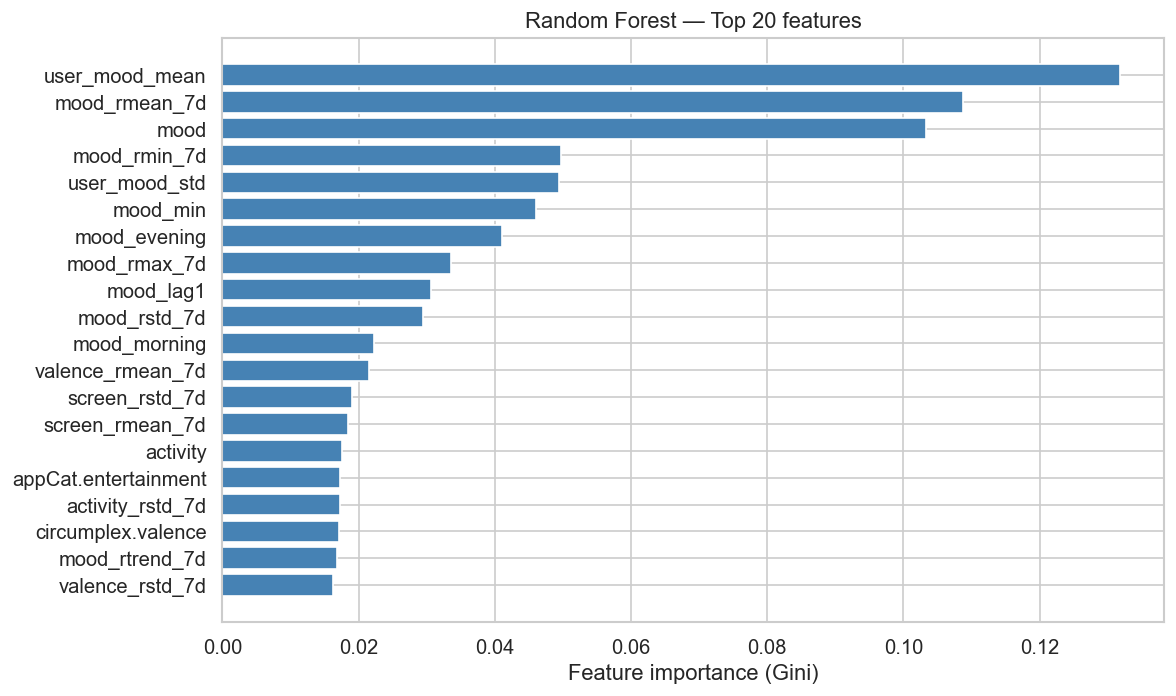

In [6]:
# --- Feature importance ---
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
top_names = [feat_cols[i] for i in sorted_idx]
top_vals  = importances[sorted_idx]
ax.barh(range(len(top_names)), top_vals[::-1], color='steelblue')
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel('Feature importance (Gini)')
ax.set_title('Random Forest — Top 20 features')
plt.tight_layout()
save_figure('2a_rf_feature_importance.png')
plt.show()


---
## 3. 1D CNN (temporal model)

### Architecture
- Conv1d(12→32, kernel=3) → ReLU → Dropout
- Conv1d(32→64, kernel=3) → ReLU → Dropout
- Global Average Pooling → Dense(64→1) → Sigmoid

Width-3 filters match the local signal structure identified by 1A's PACF (lag-1 dominates). ~7,500 parameters — deliberately small for a ~780-instance training set.

### Training
- BCE loss, Adam optimizer, early stopping (patience 15)
- Validation: last 20% of each user's training instances (temporal)


In [7]:
# --- CNN validation split (temporal, within training set) ---
train_meta = meta_seq[train_seq_mask].reset_index(drop=True)
val_frac = 0.20
cnn_train_idx, cnn_val_idx = [], []
for uid in train_meta['id'].unique():
    u_idx = train_meta[train_meta['id'] == uid].index.tolist()
    cutoff = int(len(u_idx) * (1 - val_frac))
    cnn_train_idx.extend(u_idx[:cutoff])
    cnn_val_idx.extend(u_idx[cutoff:])

X_cnn_train, y_cnn_train = X_train_seq[cnn_train_idx], y_train_seq[cnn_train_idx]
X_cnn_val,   y_cnn_val   = X_train_seq[cnn_val_idx],   y_train_seq[cnn_val_idx]

print(f'CNN train: {len(cnn_train_idx)} | CNN val: {len(cnn_val_idx)} | Test: {X_test_seq.shape[0]}')
print(f'Input shape per instance: {X_cnn_train.shape[1:]} (window × channels)')


CNN train: 605 | CNN val: 163 | Test: 269
Input shape per instance: (7, 12) (window × channels)


In [8]:
# --- Train CNN with a few learning rate options ---
import torch

best_cnn = None
best_val_loss = float('inf')
best_lr = None
best_hist = None

for lr in [1e-3, 5e-4, 2e-4]:
    model = MoodCNN(
        n_channels=X_cnn_train.shape[2],
        seq_len=X_cnn_train.shape[1],
        n_filters_1=32, n_filters_2=64,
        kernel_size=3, dropout=0.3,
    )
    hist = train_cnn(
        model, X_cnn_train, y_cnn_train.astype(np.float32),
        X_cnn_val, y_cnn_val.astype(np.float32),
        task='classification', lr=lr, batch_size=32,
        max_epochs=150, patience=15, seed=42,
    )
    final_val = hist['val_loss'][-1]
    best_ep = hist['best_epoch']
    print(f'  lr={lr:.0e}: best_val_loss={min(hist["val_loss"]):.4f} at epoch {best_ep}, '
          f'ran {hist["epochs_run"]} epochs')
    if min(hist['val_loss']) < best_val_loss:
        best_val_loss = min(hist['val_loss'])
        best_cnn = model
        best_lr = lr
        best_hist = hist

print(f'\nSelected lr={best_lr:.0e}')


  lr=1e-03: best_val_loss=0.5456 at epoch 43, ran 58 epochs


  lr=5e-04: best_val_loss=0.5433 at epoch 33, ran 48 epochs


  lr=2e-04: best_val_loss=0.5517 at epoch 75, ran 90 epochs

Selected lr=5e-04


Saved: figures/2a_cnn_training_curve.png


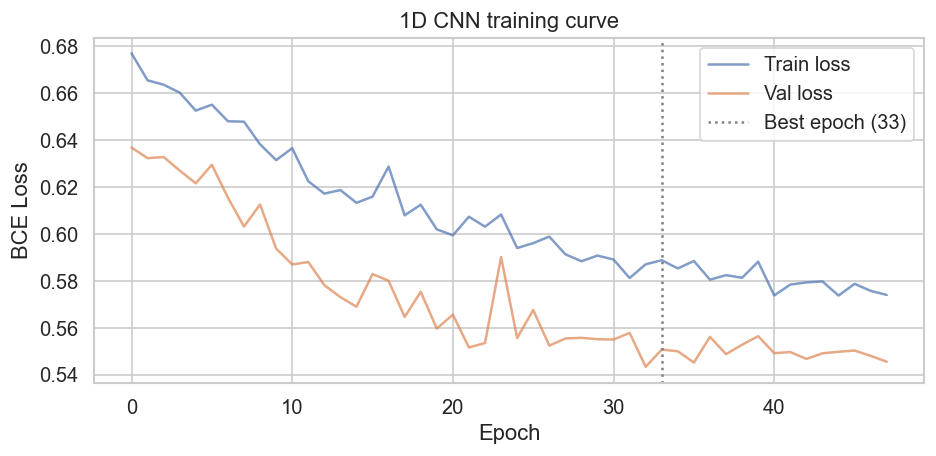

In [9]:
# --- Plot training curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_hist['train_loss'], label='Train loss', alpha=0.7)
ax.plot(best_hist['val_loss'], label='Val loss', alpha=0.7)
ax.axvline(best_hist['best_epoch'], color='grey', linestyle=':', label=f'Best epoch ({best_hist["best_epoch"]})')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('1D CNN training curve')
ax.legend()
plt.tight_layout()
save_figure('2a_cnn_training_curve.png')
plt.show()


In [10]:
# --- Evaluate CNN on test set ---
cnn_pred, cnn_prob = predict_cnn(best_cnn, X_test_seq, task='classification')

cnn_metrics = evaluate_classification(y_test_seq, cnn_pred, cnn_prob)
print('=== 1D CNN — Test Set ===')
for k, v in cnn_metrics.items():
    print(f'  {k}: {v:.3f}')
print()
print(classification_report(y_test_seq, cnn_pred, target_names=['Low', 'High']))


=== 1D CNN — Test Set ===
  Accuracy: 0.699
  Balanced Accuracy: 0.604
  F1 (macro): 0.591
  AUC-ROC: 0.694

              precision    recall  f1-score   support

         Low       0.76      0.26      0.38        98
        High       0.69      0.95      0.80       171

    accuracy                           0.70       269
   macro avg       0.72      0.60      0.59       269
weighted avg       0.72      0.70      0.65       269



---
## 4. Model comparison


=== Model Comparison ===
               Accuracy  Balanced Accuracy  F1 (macro)  AUC-ROC
Random Forest     0.736              0.723       0.719    0.799
1D CNN            0.699              0.604       0.591    0.694



Saved: figures/2a_confusion_matrices.png


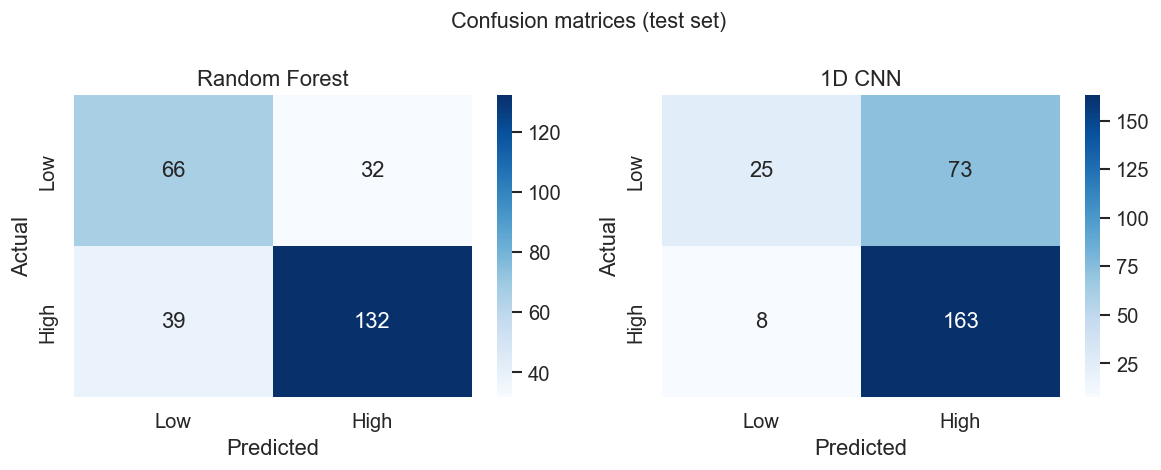

In [11]:
# --- Side-by-side metrics ---
from sklearn.metrics import confusion_matrix as cm_func

comparison = pd.DataFrame({
    'Random Forest': rf_metrics,
    '1D CNN': cnn_metrics,
}).T
print('=== Model Comparison ===')
print(comparison.round(3).to_string())
print()

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, name in [
    (axes[0], rf_pred, 'Random Forest'),
    (axes[1], cnn_pred, '1D CNN'),
]:
    cm = cm_func(y_test_rf, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.suptitle('Confusion matrices (test set)', fontsize=13)
plt.tight_layout()
save_figure('2a_confusion_matrices.png')
plt.show()


---
## Summary

| Aspect | Random Forest | 1D CNN |
|---|---|---|
| Input | 43 tabular features (aggregated) | 7 × 12 raw daily channels |
| Parameters | ~hundreds of trees | ~7,500 weights |
| Temporal awareness | Via lag/rolling features only | Directly from sequence structure |
| Tuning | RandomizedSearchCV (60 configs) | LR grid (3 options) + early stopping |
| Primary metric | Balanced accuracy | Balanced accuracy |

**Evaluation discipline:**
- Per-user temporal split (75/25) prevents lag-feature leakage
- Per-user stats recomputed on training data only
- Classification threshold τ set on training-set median
- Both models evaluated on the identical test set

**Expected finding (from model-choice analysis):** the non-temporal model (RF) likely matches or outperforms the temporal model (CNN), because the signal is local (PACF lag-1 only) and the tabular features already capture the relevant history via aggregation. The CNN's sequential view adds no information the rolling features don't already contain — but it demonstrates the temporal approach as required by the advanced track.
